# Notebook 1: Crystal Structures — Representation & Tools

**APS Tutorial T4 — Generative AI for Physics: From Models to Materials**

In this notebook you will learn to:
- Represent crystal structures in Python using **pymatgen**
- Create structures from scratch (lattice + basis)
- Load structures from CIF files
- Inspect lattice parameters, compositions, and coordinates
- Visualize unit cells in 3D

> **Prerequisites:** Run `00_setup.ipynb` first to install dependencies.

In [1]:
# --- Run once per Colab session (skip if you already ran 00_setup.ipynb) ---
import os, shutil, subprocess, sys

REPO_URL = 'https://github.com/RyotaroOKabe/APS_demo_SCIGEN.git'
PROJECT_DIR = '/content/APS_demo_SCIGEN'

# Clone repo if needed
if not os.path.exists(os.path.join(PROJECT_DIR, '.git')):
    if os.path.exists(PROJECT_DIR):
        shutil.rmtree(PROJECT_DIR)
    os.system(f'git clone {REPO_URL} {PROJECT_DIR}')

# Install all tutorial dependencies from the shared requirements file
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       '-r', f'{PROJECT_DIR}/requirements-colab.txt'])
os.environ.setdefault('PROJECT_ROOT', PROJECT_DIR)
print('Ready.')

Ready.


---
## 1.1 What is a crystal structure?

A crystal structure is defined by:
- A **lattice** — the periodic box described by three vectors **a**, **b**, **c** (or equivalently, lengths *a, b, c* and angles *α, β, γ*)
- A **basis** — the atoms inside one unit cell, given by their species and fractional coordinates

In pymatgen, these are combined into a `Structure` object.

### Fractional vs. Cartesian coordinates

Atoms in a crystal can be described two ways:
- **Cartesian coordinates** (x, y, z in Angstroms) — absolute positions in space
- **Fractional coordinates** (a, b, c in [0, 1)) — positions relative to the lattice vectors

Fractional coordinates are more natural for crystals because they are independent of the unit cell size. An atom at fractional coordinate (0.5, 0.5, 0.5) is always at the center of the cell, regardless of how large or small that cell is.

In [2]:
from pymatgen.core import Structure, Lattice
import numpy as np

### Creating a structure from scratch

Let's build a simple cubic NaCl (rock salt) structure.
The conventional cell has lattice parameter *a* ≈ 5.64 Å.

In [3]:
# Define the lattice: cubic with a = 5.64 Å
lattice = Lattice.cubic(5.64)

# Define species and fractional coordinates
species = ['Na', 'Na', 'Na', 'Na', 'Cl', 'Cl', 'Cl', 'Cl']
frac_coords = [
    [0.0, 0.0, 0.0],  # Na
    [0.5, 0.5, 0.0],  # Na
    [0.5, 0.0, 0.5],  # Na
    [0.0, 0.5, 0.5],  # Na
    [0.5, 0.0, 0.0],  # Cl
    [0.0, 0.5, 0.0],  # Cl
    [0.0, 0.0, 0.5],  # Cl
    [0.5, 0.5, 0.5],  # Cl
]

nacl = Structure(lattice, species, frac_coords)
print(nacl)

Full Formula (Na4 Cl4)
Reduced Formula: NaCl
abc   :   5.640000   5.640000   5.640000
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (8)
  #  SP      a    b    c
---  ----  ---  ---  ---
  0  Na    0    0    0
  1  Na    0.5  0.5  0
  2  Na    0.5  0    0.5
  3  Na    0    0.5  0.5
  4  Cl    0.5  0    0
  5  Cl    0    0.5  0
  6  Cl    0    0    0.5
  7  Cl    0.5  0.5  0.5


### Inspecting a structure

pymatgen structures expose all the information you need:

In [4]:
print(f'Formula:           {nacl.composition.reduced_formula}')
print(f'Number of atoms:   {nacl.num_sites}')
print(f'Volume:            {nacl.volume:.2f} Å³')
print(f'Density:           {nacl.density:.3f} g/cm³')
print()
print('Lattice parameters:')
print(f'  a={nacl.lattice.a:.2f} Å, b={nacl.lattice.b:.2f} Å, c={nacl.lattice.c:.2f} Å')
print(f'  α={nacl.lattice.alpha:.1f}°, β={nacl.lattice.beta:.1f}°, γ={nacl.lattice.gamma:.1f}°')
print()
print('Fractional coordinates:')
for site in nacl:
    print(f'  {site.species_string:>4s}  {site.frac_coords}')

Formula:           NaCl
Number of atoms:   8
Volume:            179.41 Å³
Density:           2.164 g/cm³

Lattice parameters:
  a=5.64 Å, b=5.64 Å, c=5.64 Å
  α=90.0°, β=90.0°, γ=90.0°

Fractional coordinates:
    Na  [0. 0. 0.]
    Na  [0.5 0.5 0. ]
    Na  [0.5 0.  0.5]
    Na  [0.  0.5 0.5]
    Cl  [0.5 0.  0. ]
    Cl  [0.  0.5 0. ]
    Cl  [0.  0.  0.5]
    Cl  [0.5 0.5 0.5]


---
## 1.2 Loading structures from CIF files

CIF (Crystallographic Information File) is the standard format for crystal structures.
SCIGEN's training data contains CIF strings in CSV files. Let's load one.

In [5]:
import pandas as pd
import os

# Load the SCIGEN training data (MP-20 dataset)
PROJECT_DIR = os.environ.get('PROJECT_ROOT', '/content/APS_demo_SCIGEN')
df = pd.read_csv(os.path.join(PROJECT_DIR, 'data', 'mp_20', 'train.csv'))
print(f'Dataset: {len(df)} structures')
print(f'Columns: {list(df.columns)}')

Dataset: 27136 structures
Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'material_id', 'formation_energy_per_atom', 'band_gap', 'pretty_formula', 'e_above_hull', 'elements', 'cif', 'spacegroup.number', 'spacegroup.number.conv', 'cif.conv']


In [6]:
# Look at the first few entries
df[['material_id', 'pretty_formula', 'formation_energy_per_atom',
    'e_above_hull', 'spacegroup.number']].head(10)

,material_id,pretty_formula,formation_energy_per_atom,e_above_hull,spacegroup.number
0,mp-1221227,Na3MnCoNiO6,-1.637460,0.043001,8
1,mp-974729,Nd(Al2Cu)4,-0.314759,0.000000,139
2,mp-1185360,LiMnIr2,-0.193761,0.018075,225
3,mp-1188861,LiCSN,-0.584694,0.048847,62
4,mp-677272,La2EuS4,-2.474759,0.000000,122
5,mp-1104517,Yb3Ga9Pt2,-0.641076,0.000000,71
6,mp-561310,NaLiCO3,-2.160561,0.009368,189
7,mp-777964,Na2BiO3,-1.697508,0.033273,12
8,mp-1078776,InBiS3,-0.736610,0.003336,11
9,mp-1217581,TbAlNi4,-0.521304,0.000000,65


### Browse the dataset interactively

Use the slider below to explore different structures in the training data:

In [7]:
try:
    import ipywidgets as widgets
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    from IPython.display import display, clear_output

    out = widgets.Output()

    def show_structure(idx):
        with out:
            clear_output(wait=True)
            row = df.iloc[idx]
            s = Structure.from_str(row['cif'], fmt='cif')
            print(f'#{idx}: {row["pretty_formula"]}  |  {row["material_id"]}  |  '
                  f'{s.num_sites} atoms  |  SG {row["spacegroup.number"]}  |  '
                  f'Ef = {row["formation_energy_per_atom"]:.3f} eV/atom')
            fig = plt.figure(figsize=(5, 5))
            ax = fig.add_subplot(111, projection='3d')
            plot_structure(s, title=row['pretty_formula'], ax=ax)
            plt.tight_layout()
            plt.show()

    slider = widgets.IntSlider(min=0, max=len(df)-1, step=1, value=0, description='Index:')
    widgets.interact(show_structure, idx=slider)
    display(out)
except ImportError:
    print('ipywidgets not available — skipping interactive browser.')

interactive(children=(IntSlider(value=0, description='Index:', max=27135), Output()), _dom_classes=('widget-in…

Output()

In [8]:
# Parse a CIF string into a pymatgen Structure
from pymatgen.core import Structure

row = df.iloc[0]
struct = Structure.from_str(row['cif'], fmt='cif')

print(f'Material ID: {row["material_id"]}')
print(f'Formula:     {row["pretty_formula"]}')
print(f'Atoms/cell:  {struct.num_sites}')
print(f'Space group: {row["spacegroup.number"]}')
print()
print(struct)

Material ID: mp-1221227
Formula:     Na3MnCoNiO6
Atoms/cell:  12
Space group: 8

Full Formula (Na3 Mn1 Co1 Ni1 O6)
Reduced Formula: Na3MnCoNiO6
abc   :   7.977628   7.977628   5.637114
angles:  72.488579  72.488579  21.889369
pbc   :       True       True       True
Sites (12)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Na    0.333489  0.333489  0.001785
  1  Na    0.999877  0.999877  0.999725
  2  Na    0.667975  0.667975  0.995662
  3  Mn    0.500177  0.500177  0.500733
  4  Co    0.826264  0.826264  0.493492
  5  Ni    0.167036  0.167036  0.5058
  6  O     0.927683  0.927683  0.690081
  7  O     0.581321  0.581321  0.69828
  8  O     0.258805  0.258805  0.710818
  9  O     0.070754  0.070754  0.30547
 10  O     0.751229  0.751229  0.291425
 11  O     0.415389  0.415389  0.306728


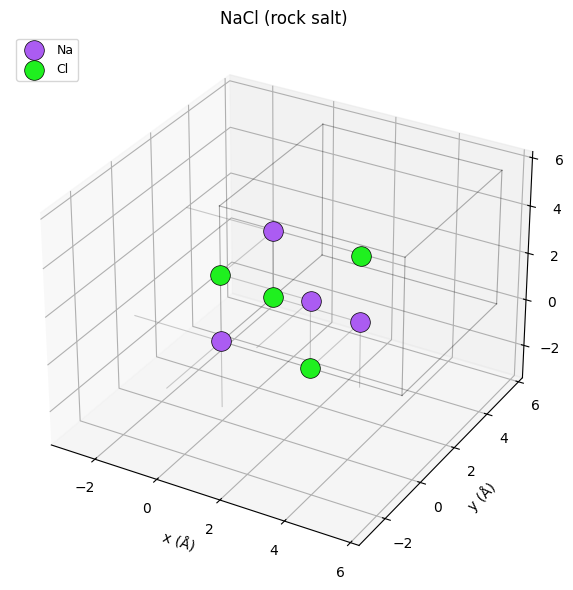

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import to_rgba

# CPK-inspired colorblind-safe palette
ELEMENT_COLORS = {
    'H': '#FFFFFF', 'Li': '#CC80FF', 'Be': '#C2FF00', 'B': '#FFB5B5',
    'C': '#404040', 'N': '#3050F8', 'O': '#FF0D0D', 'F': '#90E050',
    'Na': '#AB5CF2', 'Mg': '#8AFF00', 'Al': '#BFA6A6', 'Si': '#F0C8A0',
    'P': '#FF8000', 'S': '#FFFF30', 'Cl': '#1FF01F', 'K': '#8F40D4',
    'Ca': '#3DFF00', 'Ti': '#BFC2C7', 'V': '#A6A6AB', 'Cr': '#8A99C7',
    'Mn': '#9C7AC7', 'Fe': '#E06633', 'Co': '#F090A0', 'Ni': '#50D050',
    'Cu': '#C88033', 'Zn': '#7D80B0', 'Ga': '#C28F8F', 'Ge': '#668F8F',
    'As': '#BD80E3', 'Se': '#FFA100', 'Br': '#A62929', 'Sr': '#00FF00',
    'Y': '#94FFFF', 'Zr': '#94E0E0', 'Nb': '#73C2C9', 'Mo': '#54B5B5',
    'Ru': '#248F8F', 'Rh': '#0A7D8C', 'Pd': '#006985', 'Ag': '#C0C0C0',
    'In': '#A67573', 'Sn': '#668080', 'Sb': '#9E63B5', 'Te': '#D47A00',
    'I': '#940094', 'Ba': '#00C900', 'La': '#70D4FF', 'Ce': '#FFFFC7',
    'Bi': '#9E4FB5', 'Pb': '#575961',
}

# Fallback: use tab10 colormap for elements not in the dict
_tab10 = plt.cm.tab10

def _get_element_color(symbol, _cache={}):
    """Return a color for the given element symbol."""
    if symbol in ELEMENT_COLORS:
        return ELEMENT_COLORS[symbol]
    if symbol not in _cache:
        idx = len(_cache) % 10
        _cache[symbol] = _tab10(idx)
    return _cache[symbol]

def plot_structure(struct, title=None, ax=None, bond_cutoff=None):
    """Plot a pymatgen Structure in 3D with bonds."""
    if ax is None:
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='3d')

    # Plot atoms
    cart_coords = struct.cart_coords
    for site in struct:
        c = _get_element_color(site.species_string)
        ax.scatter(*site.coords, s=200, c=[c], edgecolors='black', linewidths=0.5,
                   depthshade=True, label=site.species_string)

    # Draw bonds using pymatgen neighbor search
    if bond_cutoff is None:
        # Heuristic: use 3.0 Å as default, reasonable for most structures
        bond_cutoff = 3.0
    all_neighbors = struct.get_all_neighbors(bond_cutoff)
    drawn = set()
    for i, neighbors in enumerate(all_neighbors):
        for neighbor in neighbors:
            j = neighbor.index
            pair = (min(i, j), max(i, j))
            if pair not in drawn:
                drawn.add(pair)
                p1 = struct[i].coords
                p2 = neighbor.coords  # uses the image coords (handles PBC)
                ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]],
                        color='gray', linewidth=0.8, alpha=0.4)

    # Draw unit cell edges
    lattice_matrix = struct.lattice.matrix
    origin = np.array([0, 0, 0])
    a, b, c = lattice_matrix
    edges = [
        (origin, a), (origin, b), (origin, c),
        (a, a+b), (a, a+c), (b, a+b), (b, b+c),
        (c, a+c), (c, b+c), (a+b, a+b+c), (a+c, a+b+c), (b+c, a+b+c)
    ]
    for start, end in edges:
        ax.plot(*zip(start, end), 'k-', alpha=0.3, linewidth=0.8)

    # De-duplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=9)

    if title:
        ax.set_title(title, fontsize=12)
    ax.set_xlabel('x (Å)')
    ax.set_ylabel('y (Å)')
    ax.set_zlabel('z (Å)')
    return ax

# Visualize NaCl
plot_structure(nacl, title='NaCl (rock salt)')
plt.tight_layout()
plt.show()

In [10]:
# Save to CIF
cif_string = struct.to(fmt='cif')
print(cif_string[:500])

# generated using pymatgen
data_Na3MnCoNiO6
_symmetry_space_group_name_H-M   'P 1'
_cell_length_a   7.97762755
_cell_length_b   7.97762755
_cell_length_c   5.63711369
_cell_angle_alpha   72.48857871
_cell_angle_beta   72.48857871
_cell_angle_gamma   21.88936910
_symmetry_Int_Tables_number   1
_chemical_formula_structural   Na3MnCoNiO6
_chemical_formula_sum   'Na3 Mn1 Co1 Ni1 O6'
_cell_volume   127.31533276
_cell_formula_units_Z   1
loop_
 _symmetry_equiv_pos_site_id
 _symmetry_equiv_pos_as_xyz
 


---
## 1.4 Visualizing crystal structures

Let's visualize a unit cell using matplotlib. We'll plot atoms as spheres
colored by element, and draw the unit cell box.

### Why are kagome materials interesting?

The kagome lattice creates **geometric frustration** in magnetic materials. On a triangle of antiferromagnetically coupled spins, it's impossible for all three spins to be antiparallel to each other simultaneously. This frustration suppresses conventional magnetic order and can give rise to:

- **Quantum spin liquids** — exotic states with long-range entanglement but no magnetic order
- **Flat electronic bands** — leading to strongly correlated electron physics
- **Anomalous Hall effects** — useful for spintronic devices

Despite their scientific importance, kagome materials are **rare in nature**. This is exactly the gap that SCIGEN aims to fill.

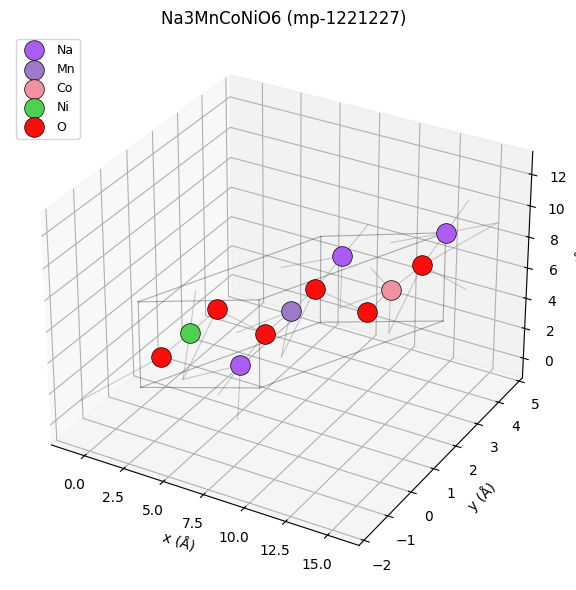

In [11]:
# Visualize the structure we loaded from the dataset
plot_structure(struct, title=f'{row["pretty_formula"]} ({row["material_id"]})')
plt.tight_layout()
plt.show()

---
## Exercise

1. Pick a different structure from the training data (`df.iloc[100]`, for example). Parse it, print the formula and number of atoms, and visualize it.
2. Try building a **honeycomb** lattice (2 atoms per cell at [1/3, 2/3, 0] and [2/3, 1/3, 0] in a hexagonal cell). Visualize it as a supercell.
3. Create a 2x2x1 supercell of the kagome structure. How does the bond pattern look different from the single cell?

Unit cell: 8 atoms
2x2x2 supercell: 64 atoms


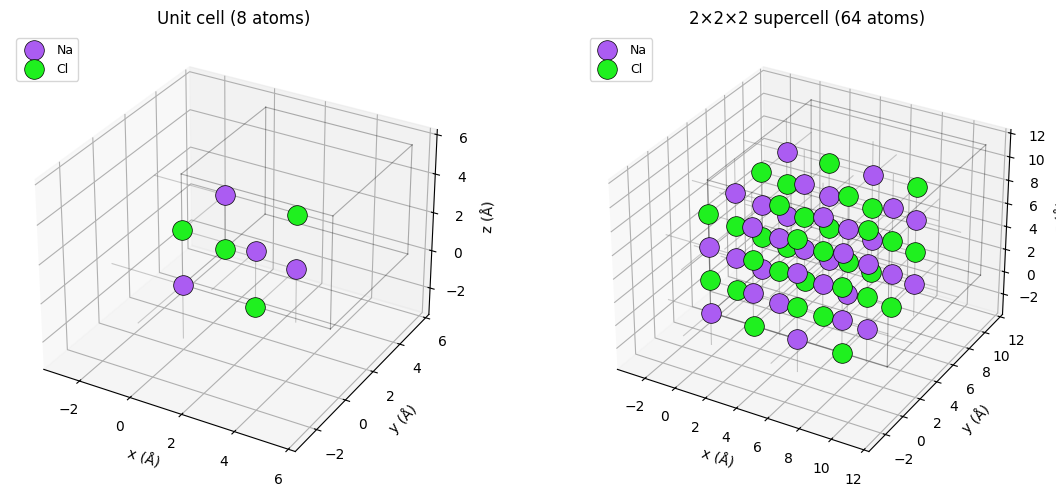

In [12]:
# Show periodicity: 2x2x2 supercell of NaCl
supercell_nacl = nacl.copy()
supercell_nacl.make_supercell([2, 2, 2])

print(f'Unit cell: {nacl.num_sites} atoms')
print(f'2x2x2 supercell: {supercell_nacl.num_sites} atoms')

fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': '3d'})
plot_structure(nacl, title='Unit cell (8 atoms)', ax=axes[0])
plot_structure(supercell_nacl, title='2\u00d72\u00d72 supercell (64 atoms)', ax=axes[1])
plt.tight_layout()
plt.show()

---
## 1.5 The kagome lattice — our running example

The **kagome lattice** is a pattern of corner-sharing triangles that appears in many
frustrated magnets. It is one of the key structural constraints that SCIGEN can target.

Let's build a simple kagome lattice to see what it looks like.

In [13]:
# Build a simple kagome lattice with Mn atoms
# Hexagonal cell: a = b, gamma = 120°
a_lat = 5.0  # Å
lattice_kag = Lattice.hexagonal(a_lat, 6.0)  # a=b=5.0, c=6.0, gamma=120°

# Kagome sites: 3 atoms per unit cell at specific fractional positions
kagome_frac = [
    [0.5, 0.0, 0.0],
    [0.0, 0.5, 0.0],
    [0.5, 0.5, 0.0],
]

kagome_struct = Structure(lattice_kag, ['Mn'] * 3, kagome_frac)

print('Kagome lattice with Mn:')
print(f'  a = {lattice_kag.a:.2f} Å, c = {lattice_kag.c:.2f} Å, γ = {lattice_kag.gamma:.0f}°')
print(f'  Atoms per cell: {kagome_struct.num_sites}')
print()
print(kagome_struct)

Kagome lattice with Mn:
  a = 5.00 Å, c = 6.00 Å, γ = 120°
  Atoms per cell: 3

Full Formula (Mn3)
Reduced Formula: Mn
abc   :   5.000000   5.000000   6.000000
angles:  90.000000  90.000000 120.000000
pbc   :       True       True       True
Sites (3)
  #  SP      a    b    c
---  ----  ---  ---  ---
  0  Mn    0.5  0      0
  1  Mn    0    0.5    0
  2  Mn    0.5  0.5    0


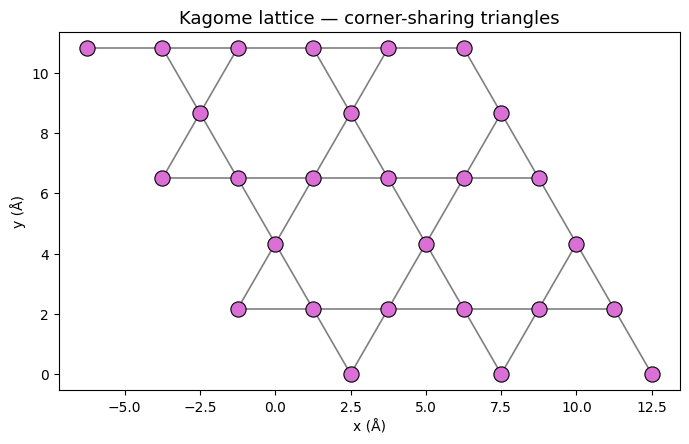

In [14]:
# Visualize the kagome lattice
# We'll plot a 2x2 supercell in 2D to see the triangular pattern
import matplotlib.pyplot as plt
import numpy as np
from pymatgen.core import Structure, Lattice

# Ensure kagome_struct exists (recreate if cell above was skipped)
if 'kagome_struct' not in dir():
    a_lat = 5.0
    lattice_kag = Lattice.hexagonal(a_lat, 6.0)
    kagome_frac = [[0.5, 0.0, 0.0], [0.0, 0.5, 0.0], [0.5, 0.5, 0.0]]
    kagome_struct = Structure(lattice_kag, ['Mn'] * 3, kagome_frac)
else:
    a_lat = kagome_struct.lattice.a

fig, ax = plt.subplots(figsize=(7, 6))

# Create a 3x3 supercell to see the kagome pattern clearly
supercell = kagome_struct.copy()
supercell.make_supercell([3, 3, 1])

# Plot atom positions (projected onto xy plane)
coords = supercell.cart_coords
ax.scatter(coords[:, 0], coords[:, 1], s=120, c='orchid',
           edgecolors='black', linewidths=0.8, zorder=5)

# Draw bonds (connect atoms within ~0.6*a of each other)
from scipy.spatial.distance import cdist
dists = cdist(coords[:, :2], coords[:, :2])
bond_cutoff = a_lat * 0.6
for i in range(len(coords)):
    for j in range(i+1, len(coords)):
        if dists[i, j] < bond_cutoff:
            ax.plot([coords[i, 0], coords[j, 0]],
                    [coords[i, 1], coords[j, 1]],
                    'k-', linewidth=1.2, alpha=0.5)

ax.set_aspect('equal')
ax.set_title('Kagome lattice — corner-sharing triangles', fontsize=13)
ax.set_xlabel('x (Å)')
ax.set_ylabel('y (Å)')
plt.tight_layout()
plt.show()

The kagome pattern of corner-sharing triangles leads to **geometric frustration**
in magnetic materials — spins on a triangle cannot all be antiparallel to each other.
This frustration gives rise to exotic quantum states like spin liquids.

In Notebook 05, we will use SCIGEN to **generate new crystal structures** that
contain this kagome sublattice.

---
## Exercise

1. Pick a different structure from the training data (`df.iloc[100]`, for example). Parse it, print the formula and number of atoms, and visualize it.
2. Try building a **honeycomb** lattice (2 atoms per cell at [1/3, 2/3, 0] and [2/3, 1/3, 0] in a hexagonal cell). Visualize it as a supercell.

---
## 1.6 Publication-quality 3D visualization

The matplotlib 3D plots above are fine for quick inspection, but for publication-quality
rendering we can use **PyVista** — a 3D visualization library built on VTK.

The helper module `scripts/crystal_viz.py` provides:
- Jmol-standard element colors and van-der-Waals radii
- Periodic boundary atom images (atoms at cell faces appear on both sides)
- Unit cell wireframe with supercell support
- Off-screen rendering for Colab compatibility

/content/APS_demo_SCIGEN/scripts/crystal_viz.py:197: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk with osmesa instead.
  pv.start_xvfb()


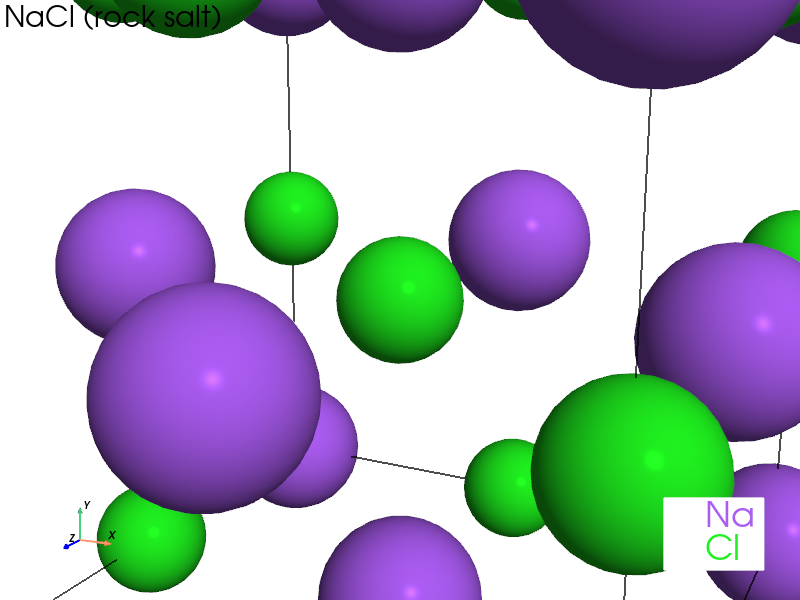

In [15]:
import sys, os
PROJECT_DIR = os.environ.get('PROJECT_ROOT', '/content/APS_demo_SCIGEN')
if os.path.join(PROJECT_DIR, 'scripts') not in sys.path:
    sys.path.insert(0, os.path.join(PROJECT_DIR, 'scripts'))

try:
    from crystal_viz import plot_crystal, plot_crystal_grid

    # Render NaCl with PyVista (Jmol colors, unit cell wireframe)
    img_nacl = plot_crystal(nacl, title='NaCl (rock salt)',
                            atom_scale=0.3, elevation=60)
except ImportError as e:
    print(f'PyVista not available ({e}) — skipping 3D rendering.')
    print('Install with: pip install pyvista')
except Exception as e:
    print(f'3D rendering failed: {e}')
    print('This is expected if running without a display server.')

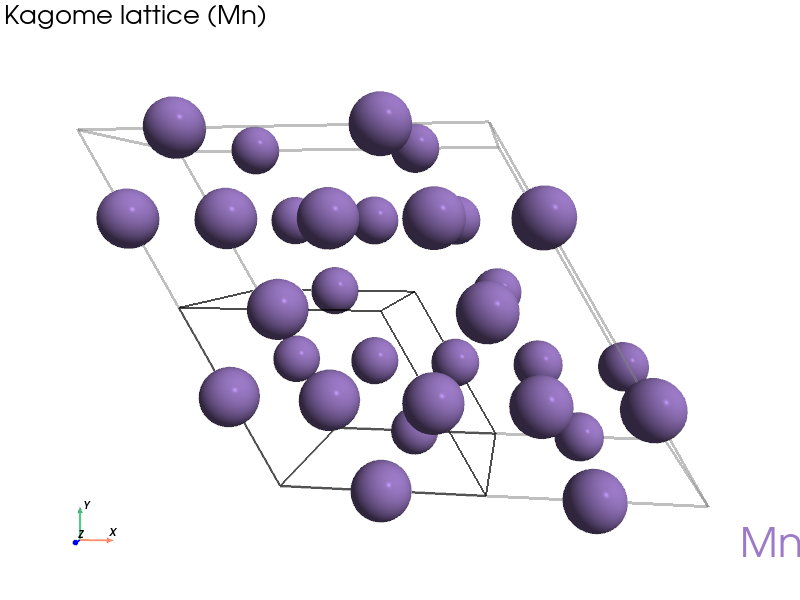

In [16]:
try:
    # Render kagome lattice as 2x2x1 supercell
    img_kag = plot_crystal(kagome_struct, title='Kagome lattice (Mn)',
                           supercell=(2, 2, 1), atom_scale=0.3, elevation=80)
except Exception as e:
    print(f'Kagome rendering skipped: {e}')

---
## 1.7 Space group analysis

Every crystal structure belongs to one of 230 **space groups** — symmetry classifications
that describe the rotations, reflections, and translations that leave the structure invariant.

Pymatgen can automatically determine the space group of any structure using the
`SpacegroupAnalyzer` class.

In [17]:
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

# Analyze NaCl
sga_nacl = SpacegroupAnalyzer(nacl)
print('=== NaCl ===')
print(f'  Space group symbol:  {sga_nacl.get_space_group_symbol()}')
print(f'  Space group number:  {sga_nacl.get_space_group_number()}')
print(f'  Crystal system:      {sga_nacl.get_crystal_system()}')
print(f'  Point group:         {sga_nacl.get_point_group_symbol()}')
print(f'  Lattice type:        {sga_nacl.get_lattice_type()}')
print()

# Analyze the structure loaded from dataset
sga_ds = SpacegroupAnalyzer(struct)
print(f'=== {row["pretty_formula"]} ({row["material_id"]}) ===')
print(f'  Space group symbol:  {sga_ds.get_space_group_symbol()}')
print(f'  Space group number:  {sga_ds.get_space_group_number()}')
print(f'  Crystal system:      {sga_ds.get_crystal_system()}')
print(f'  Point group:         {sga_ds.get_point_group_symbol()}')
print(f'  Lattice type:        {sga_ds.get_lattice_type()}')
print()

# Analyze kagome lattice
sga_kag = SpacegroupAnalyzer(kagome_struct)
print(f'=== Kagome (Mn) ===')
print(f'  Space group symbol:  {sga_kag.get_space_group_symbol()}')
print(f'  Space group number:  {sga_kag.get_space_group_number()}')
print(f'  Crystal system:      {sga_kag.get_crystal_system()}')

=== NaCl ===
  Space group symbol:  Fm-3m
  Space group number:  225
  Crystal system:      cubic
  Point group:         m-3m
  Lattice type:        cubic

=== Na3MnCoNiO6 (mp-1221227) ===
  Space group symbol:  Cm
  Space group number:  8
  Crystal system:      monoclinic
  Point group:         m
  Lattice type:        monoclinic

=== Kagome (Mn) ===
  Space group symbol:  P6/mmm
  Space group number:  191
  Crystal system:      hexagonal


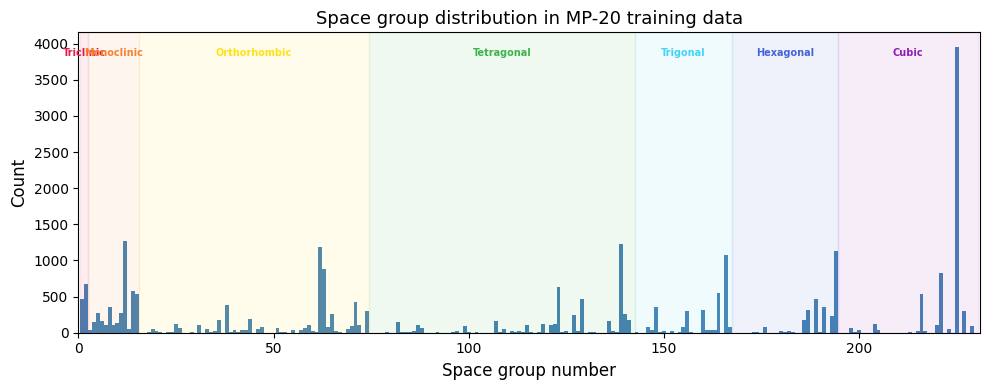

In [18]:
import matplotlib.pyplot as plt

# Space group distribution in the training data
sg_counts = df['spacegroup.number'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(sg_counts.index, sg_counts.values, width=1.0, color='steelblue', edgecolor='none')
ax.set_xlabel('Space group number', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Space group distribution in MP-20 training data', fontsize=13)
ax.set_xlim(0, 231)

# Mark the 7 crystal systems
systems = [(1, 2, 'Triclinic'), (3, 15, 'Monoclinic'), (16, 74, 'Orthorhombic'),
           (75, 142, 'Tetragonal'), (143, 167, 'Trigonal'),
           (168, 194, 'Hexagonal'), (195, 230, 'Cubic')]
colors = ['#e6194b', '#f58231', '#ffe119', '#3cb44b', '#42d4f4', '#4363d8', '#911eb4']
for (lo, hi, name), c in zip(systems, colors):
    ax.axvspan(lo - 0.5, hi + 0.5, alpha=0.08, color=c)
    ax.text((lo + hi) / 2, ax.get_ylim()[1] * 0.92, name,
            ha='center', fontsize=7, color=c, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 1.8 Simulated X-ray diffraction (XRD)

X-ray diffraction is the primary experimental technique for determining crystal structures.
Pymatgen can simulate the **powder XRD pattern** from any structure, which is useful for:
- Comparing generated structures against experimental data
- Identifying the crystal phase of a material
- Validating that a generated structure matches the intended symmetry

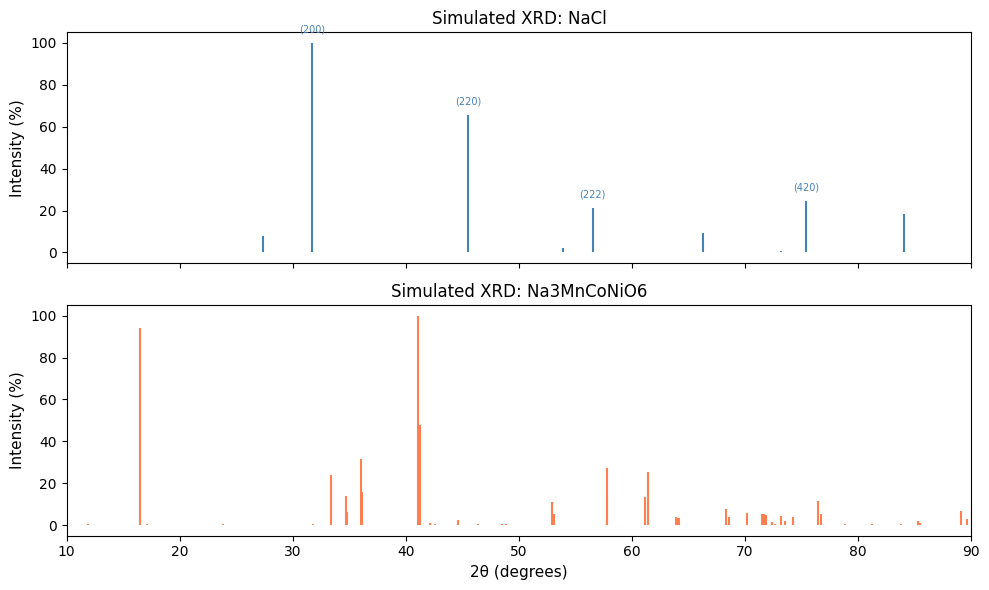

NaCl: 9 reflections
Na3MnCoNiO6: 131 reflections


In [19]:
from pymatgen.analysis.diffraction.xrd import XRDCalculator

xrd_calc = XRDCalculator(wavelength='CuKa')  # Cu Kα radiation (1.5406 Å)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# NaCl XRD pattern
pattern_nacl = xrd_calc.get_pattern(nacl)
axes[0].stem(pattern_nacl.x, pattern_nacl.y, linefmt='steelblue', markerfmt=' ', basefmt=' ')
axes[0].set_ylabel('Intensity (%)', fontsize=11)
axes[0].set_title('Simulated XRD: NaCl', fontsize=12)
axes[0].set_xlim(10, 90)
# Label the strongest peaks
for x, y, hkl in zip(pattern_nacl.x, pattern_nacl.y, pattern_nacl.hkls):
    if y > 20:
        label = ''.join(str(i) for i in hkl[0]['hkl'])
        axes[0].annotate(f'({label})', xy=(x, y), xytext=(x, y + 5),
                         fontsize=7, ha='center', color='steelblue')

# Dataset structure XRD pattern
pattern_ds = xrd_calc.get_pattern(struct)
axes[1].stem(pattern_ds.x, pattern_ds.y, linefmt='coral', markerfmt=' ', basefmt=' ')
axes[1].set_xlabel('2θ (degrees)', fontsize=11)
axes[1].set_ylabel('Intensity (%)', fontsize=11)
axes[1].set_title(f'Simulated XRD: {row["pretty_formula"]}', fontsize=12)
axes[1].set_xlim(10, 90)

plt.tight_layout()
plt.show()

print(f'NaCl: {len(pattern_nacl.x)} reflections')
print(f'{row["pretty_formula"]}: {len(pattern_ds.x)} reflections')

---
## What's next?

In **Notebook 02**, we'll connect to the **Materials Project** database to explore what known materials exist — and motivate why we need generative models to discover new ones.